# YOLO26 — 과수원 로봇 주행 객체 탐지 - Colab 용

[AI Hub 과수원 내 로봇 주행 데이터(사과, 배 류)](https://aihub.or.kr/aihubdata/data/view.do?dataSetSn=71700) 샘플을 이용해  
**Ultralytics YOLO26**로 과수원 전방 객체를 학습하고, 주행 시퀀스에서 모니터링하는 예제입니다.

| 항목 | 설명 |
|------|------|
| 데이터 | `과수원 내 로봇 주행 데이터(사과, 배 류).zip` 또는 `orchard_robot.zip` |
| 클래스 | 사람, 손수레, 운반차, 트럭, 방제기, 사다리, 과수박스, 창고, 사과, 배_봉지 |
| 모델 | **YOLO26s** (`yolo26s.pt`) |
| 선행 EDA | `17_Orchard_Robot_EDA.ipynb` |

<br>

> Colab: **런타임 → GPU** 를 선택한 뒤, 섹션 1에서 zip을 `/content`에 두거나 업로드하세요.  
> 학습에는 **BBX(2D 바운딩박스)** 만 사용합니다.

## 0. 환경 설정

In [3]:
# %pip install -U ultralytics

In [4]:
import sys
from pathlib import Path

import torch
import yaml
from IPython.display import Image, display
from ultralytics import YOLO, __version__

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DEVICE = 0 if torch.cuda.is_available() else "cpu"

DATA_DIR_NAME = "과수원 내 로봇 주행 데이터(사과, 배 류)"
ZIP_CANDIDATES = [
    DATA_DIR_NAME + ".zip",
    "orchard_robot.zip",
]
RAW_DIR_NAME = "01.원천데이터"
LABEL_DIR_NAME = "02.라벨링데이터"

ROOT = Path("/content") if IN_COLAB else Path.cwd()


def find_zip(root: Path) -> Path:
    for name in ZIP_CANDIDATES:
        p = root / name
        if p.exists():
            return p
    for p in root.glob("*.zip"):
        n = p.name
        if "orchard" in n.lower() or "과수원" in n:
            return p
    return root / ZIP_CANDIDATES[0]


if not any((ROOT / n).exists() for n in ZIP_CANDIDATES) and not (ROOT / DATA_DIR_NAME).exists():
    for parent in [ROOT, *ROOT.parents]:
        if any((parent / n).exists() for n in ZIP_CANDIDATES) or (parent / DATA_DIR_NAME).exists():
            ROOT = parent
            break

ZIP_PATH = find_zip(ROOT)
# Colab에서는 한글 경로 문제를 피하기 위해 ASCII 폴더로 해제
DATA_ROOT = ROOT / "orchard_robot"
if (ROOT / DATA_DIR_NAME).exists():
    DATA_ROOT = ROOT / DATA_DIR_NAME
YOLO_DIR = ROOT / "orchard_robot_yolo"
YAML_PATH = YOLO_DIR / "orchard_robot.yaml"

MODEL_NAME = "yolo26s.pt"
# YOLO26 소규모 데이터셋은 confidence가 낮게 나옴 → 0.25면 탐지 0건
CONF_THRESH = 0.10
EXPERIMENT = "yolo26_orchard_robot"

print(f"환경       : {'Colab' if IN_COLAB else '로컬'}")
print(f"Ultralytics: {__version__}")
print(f"Device     : {DEVICE} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")
print(f"ROOT       : {ROOT.resolve()}")
print(f"ZIP_PATH   : {ZIP_PATH}  (존재: {ZIP_PATH.exists()})")
print(f"DATA_ROOT  : {DATA_ROOT.resolve()}")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
환경       : Colab
Ultralytics: 8.4.142
Device     : 0 (NVIDIA A100-SXM4-40GB)
ROOT       : /content
ZIP_PATH   : /content/과수원 내 로봇 주행 데이터(사과, 배 류).zip  (존재: True)
DATA_ROOT  : /content/orchard_robot


## 1. 데이터 준비 (압축 해제 + YOLO 변환) - Colab 용

In [5]:
import json
import shutil
import zipfile

# BBX에 등장하는 10종 (SEG 전용 비포장/나무 등은 검출 학습에서 제외)
CLASS_NAMES = [
    "사람", "손수레", "운반차", "트럭", "방제기",
    "사다리", "과수박스", "창고", "사과", "배_봉지",
]
NAME_TO_ID = {n: i for i, n in enumerate(CLASS_NAMES)}

# 시퀀스 단위 val 분리 (프레임 랜덤 분할 시 인접 프레임 누수 방지)
VAL_SEQUENCES = {
    "AP_001_TP_20231102_PM_000_008_006",  # 사과
    "PE_001_TP_20231110_PM_001_006_002",  # 배
}


def data_is_ready(root: Path) -> bool:
    if not root.exists():
        return False
    jpgs = [p for p in root.rglob("*.jpg") if "eda" not in p.parts]
    jsons = [p for p in root.rglob("*_BBX.json") if "eda" not in p.parts]
    return len(jpgs) > 0 and len(jsons) > 0


def has_correct_korean_paths(root: Path) -> bool:
    if not root.exists():
        return False
    dirs = [p.name for p in root.iterdir() if p.is_dir() and p.name != "eda"]
    return RAW_DIR_NAME in dirs and LABEL_DIR_NAME in dirs


def decode_zip_name(info) -> str:
    """AI Hub zip — UTF-8 / CP949 / latin-1 폴백 (Colab 한글 파일명)."""
    try:
        if info.flag_bits & 0x800:
            return info.filename
        return info.filename.encode("cp437").decode("cp949")
    except (UnicodeEncodeError, UnicodeDecodeError):
        try:
            return info.filename.encode("latin-1").decode("cp949")
        except Exception:
            return info.filename


def extract_zip(zip_path: Path, extract_to: Path, force: bool = False) -> None:
    if not zip_path.exists():
        raise FileNotFoundError(f"압축 파일이 없습니다: {zip_path}")
    extract_to.mkdir(parents=True, exist_ok=True)
    if not force and data_is_ready(extract_to) and has_correct_korean_paths(extract_to):
        return
    for child in list(extract_to.iterdir()):
        if child.is_dir() and child.name != "eda":
            shutil.rmtree(child)
    with zipfile.ZipFile(zip_path) as zf:
        for info in zf.infolist():
            name = decode_zip_name(info)
            target = extract_to / name
            if info.is_dir() or name.endswith("/"):
                target.mkdir(parents=True, exist_ok=True)
            else:
                target.parent.mkdir(parents=True, exist_ok=True)
                with zf.open(info) as src, open(target, "wb") as dst:
                    dst.write(src.read())


def unwrap_extracted(root: Path) -> Path:
    """zip 최상위에 한글 폴더가 한 겹 더 있으면 그 안으로 들어갑니다."""
    if has_correct_korean_paths(root):
        return root
    subs = [p for p in root.iterdir() if p.is_dir() and p.name != "eda"]
    if len(subs) == 1 and has_correct_korean_paths(subs[0]):
        return subs[0]
    return root


def find_raw_and_label_roots(root: Path) -> tuple[Path, Path]:
    raw, label = root / RAW_DIR_NAME, root / LABEL_DIR_NAME
    if raw.exists() and label.exists():
        return raw, label
    candidates = [p for p in root.iterdir() if p.is_dir() and p.name not in {"eda", "images", "labels"}]
    if not candidates:
        return raw, label
    return (
        max(candidates, key=lambda p: len(list(p.rglob("*.jpg")))),
        max(candidates, key=lambda p: len(list(p.rglob("*.json")))),
    )


def coco_to_yolo(x, y, w, h, img_w, img_h):
    x = max(0.0, float(x))
    y = max(0.0, float(y))
    w = min(float(w), img_w - x)
    h = min(float(h), img_h - y)
    if w <= 1 or h <= 1:
        return None
    return (x + w / 2) / img_w, (y + h / 2) / img_h, w / img_w, h / img_h


def json_to_image_path(json_path: Path, raw_root: Path, label_root: Path) -> Path | None:
    data = json.loads(json_path.read_text(encoding="utf-8-sig"))
    file_name = data["images"][0]["file_name"]
    rel_seq = json_path.parent.parent.relative_to(label_root)
    img_path = raw_root / rel_seq / "IMG" / file_name
    return img_path if img_path.exists() else None


def prepare_yolo_dataset(root: Path, output_dir: Path) -> dict:
    raw_root, label_root = find_raw_and_label_roots(root)
    for split in ("train", "val"):
        (output_dir / "images" / split).mkdir(parents=True, exist_ok=True)
        (output_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

    stats = {"train": 0, "val": 0, "skipped": 0, "objects": 0}
    for json_path in sorted(label_root.rglob("*_BBX.json")):
        data = json.loads(json_path.read_text(encoding="utf-8-sig"))
        seq_name = json_path.parent.parent.name
        split = "val" if seq_name in VAL_SEQUENCES else "train"
        src_img = json_to_image_path(json_path, raw_root, label_root)
        if src_img is None:
            stats["skipped"] += 1
            continue

        img_info = data["images"][0]
        img_w, img_h = int(img_info["width"]), int(img_info["height"])
        cats = {c["id"]: c["name"] for c in data.get("categories", [])}

        stem = src_img.stem
        dst_img = output_dir / "images" / split / src_img.name
        dst_lbl = output_dir / "labels" / split / f"{stem}.txt"
        shutil.copy2(src_img, dst_img)

        lines = []
        for ann in data.get("annotations", []):
            name = cats.get(ann.get("category_id"))
            if name not in NAME_TO_ID:
                continue
            bbox = ann.get("bbox")
            if not bbox or len(bbox) != 4:
                continue
            yolo = coco_to_yolo(*bbox, img_w, img_h)
            if yolo is None:
                continue
            xc, yc, nw, nh = yolo
            lines.append(f"{NAME_TO_ID[name]} {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}")
            stats["objects"] += 1

        dst_lbl.write_text("\n".join(lines) + ("\n" if lines else ""), encoding="utf-8")
        stats[split] += 1

    YAML_PATH.write_text(
        f"path: {output_dir.resolve()}\n"
        f"train: images/train\n"
        f"val: images/val\n"
        f"nc: {len(CLASS_NAMES)}\n"
        f"names:\n" + "".join(f"  {i}: {n}\n" for i, n in enumerate(CLASS_NAMES)),
        encoding="utf-8",
    )
    stats["yaml"] = str(YAML_PATH)
    return stats


# Colab: zip이 없으면 업로드
if IN_COLAB and not ZIP_PATH.exists() and not data_is_ready(DATA_ROOT):
    from google.colab import files

    print("데이터 zip을 업로드하세요.")
    print("  - 과수원 내 로봇 주행 데이터(사과, 배 류).zip")
    print("  - 또는 orchard_robot.zip")
    files.upload()
    ZIP_PATH = find_zip(ROOT)

DATA_ROOT.mkdir(parents=True, exist_ok=True)
need_extract = not data_is_ready(DATA_ROOT) or not has_correct_korean_paths(DATA_ROOT)
if need_extract:
    extract_zip(ZIP_PATH, DATA_ROOT, force=True)
    DATA_ROOT = unwrap_extracted(DATA_ROOT)
    print("압축 해제 완료 (CP949 인코딩 적용)")
else:
    print("데이터 폴더 사용 (이미 압축 해제됨)")

print(f"DATA_ROOT  : {DATA_ROOT.resolve()}")

for cache in YOLO_DIR.rglob("*.cache"):
    cache.unlink(missing_ok=True)

stats = prepare_yolo_dataset(DATA_ROOT, YOLO_DIR)
print("YOLO 데이터셋:", stats)

cfg = yaml.safe_load(YAML_PATH.read_text(encoding="utf-8"))
print("클래스:", cfg["names"])
print(f"train 이미지: {len(list((YOLO_DIR / 'images/train').glob('*.jpg')))}")
print(f"val   이미지: {len(list((YOLO_DIR / 'images/val').glob('*.jpg')))}")

압축 해제 완료 (CP949 인코딩 적용)
DATA_ROOT  : /content/orchard_robot
YOLO 데이터셋: {'train': 450, 'val': 60, 'skipped': 0, 'objects': 1418, 'yaml': '/content/orchard_robot_yolo/orchard_robot.yaml'}
클래스: {0: '사람', 1: '손수레', 2: '운반차', 3: '트럭', 4: '방제기', 5: '사다리', 6: '과수박스', 7: '창고', 8: '사과', 9: '배_봉지'}
train 이미지: 450
val   이미지: 60


## 2. YOLO26 모델 학습

In [6]:
# RTX 3060 기준 약 23분 소요
# Colab A100 기준 약 12분 소요
model = YOLO(MODEL_NAME)

results = model.train(
    data=str(YAML_PATH),
    epochs=80,
    imgsz=640,
    batch=8,
    device=DEVICE,
    name=EXPERIMENT,
    exist_ok=True,
    patience=40,
    lr0=0.001,
    mosaic=0.5,
    mixup=0.0,
    copy_paste=0.0,
    close_mosaic=10,
    freeze=10,         # 샘플 데이터 과적합 완화
    workers=0,
    plots=True,
)

BEST_WEIGHTS = Path(results.save_dir) / "weights" / "best.pt"
print(f"최적 가중치: {BEST_WEIGHTS.resolve()}")
print(f"※ 추론 시 conf={CONF_THRESH} 사용 (YOLO26은 confidence가 낮게 출력되는 경향)")

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/orchard_robot_yolo/orchard_robot.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=yolo26_orchard_robo

## 3. 검증 (Validation)

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO26s summary (fused): 120 layers, 9,469,050 parameters, 0 gradients, 20.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4423.3±797.0 MB/s, size: 570.7 KB)
val: Scanning /content/orchard_robot_yolo/labels/val.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 22.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.7it/s 1.1s
                   all         60        202      0.616      0.246      0.299      0.178
                    사람          1          2          1          0          0          0
                    창고         30         30      0.847      0.737      0.898      0.533
                  배_봉지         30        170          0          0          0          0
Speed: 2.1ms preprocess, 7.3ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /content/runs/de

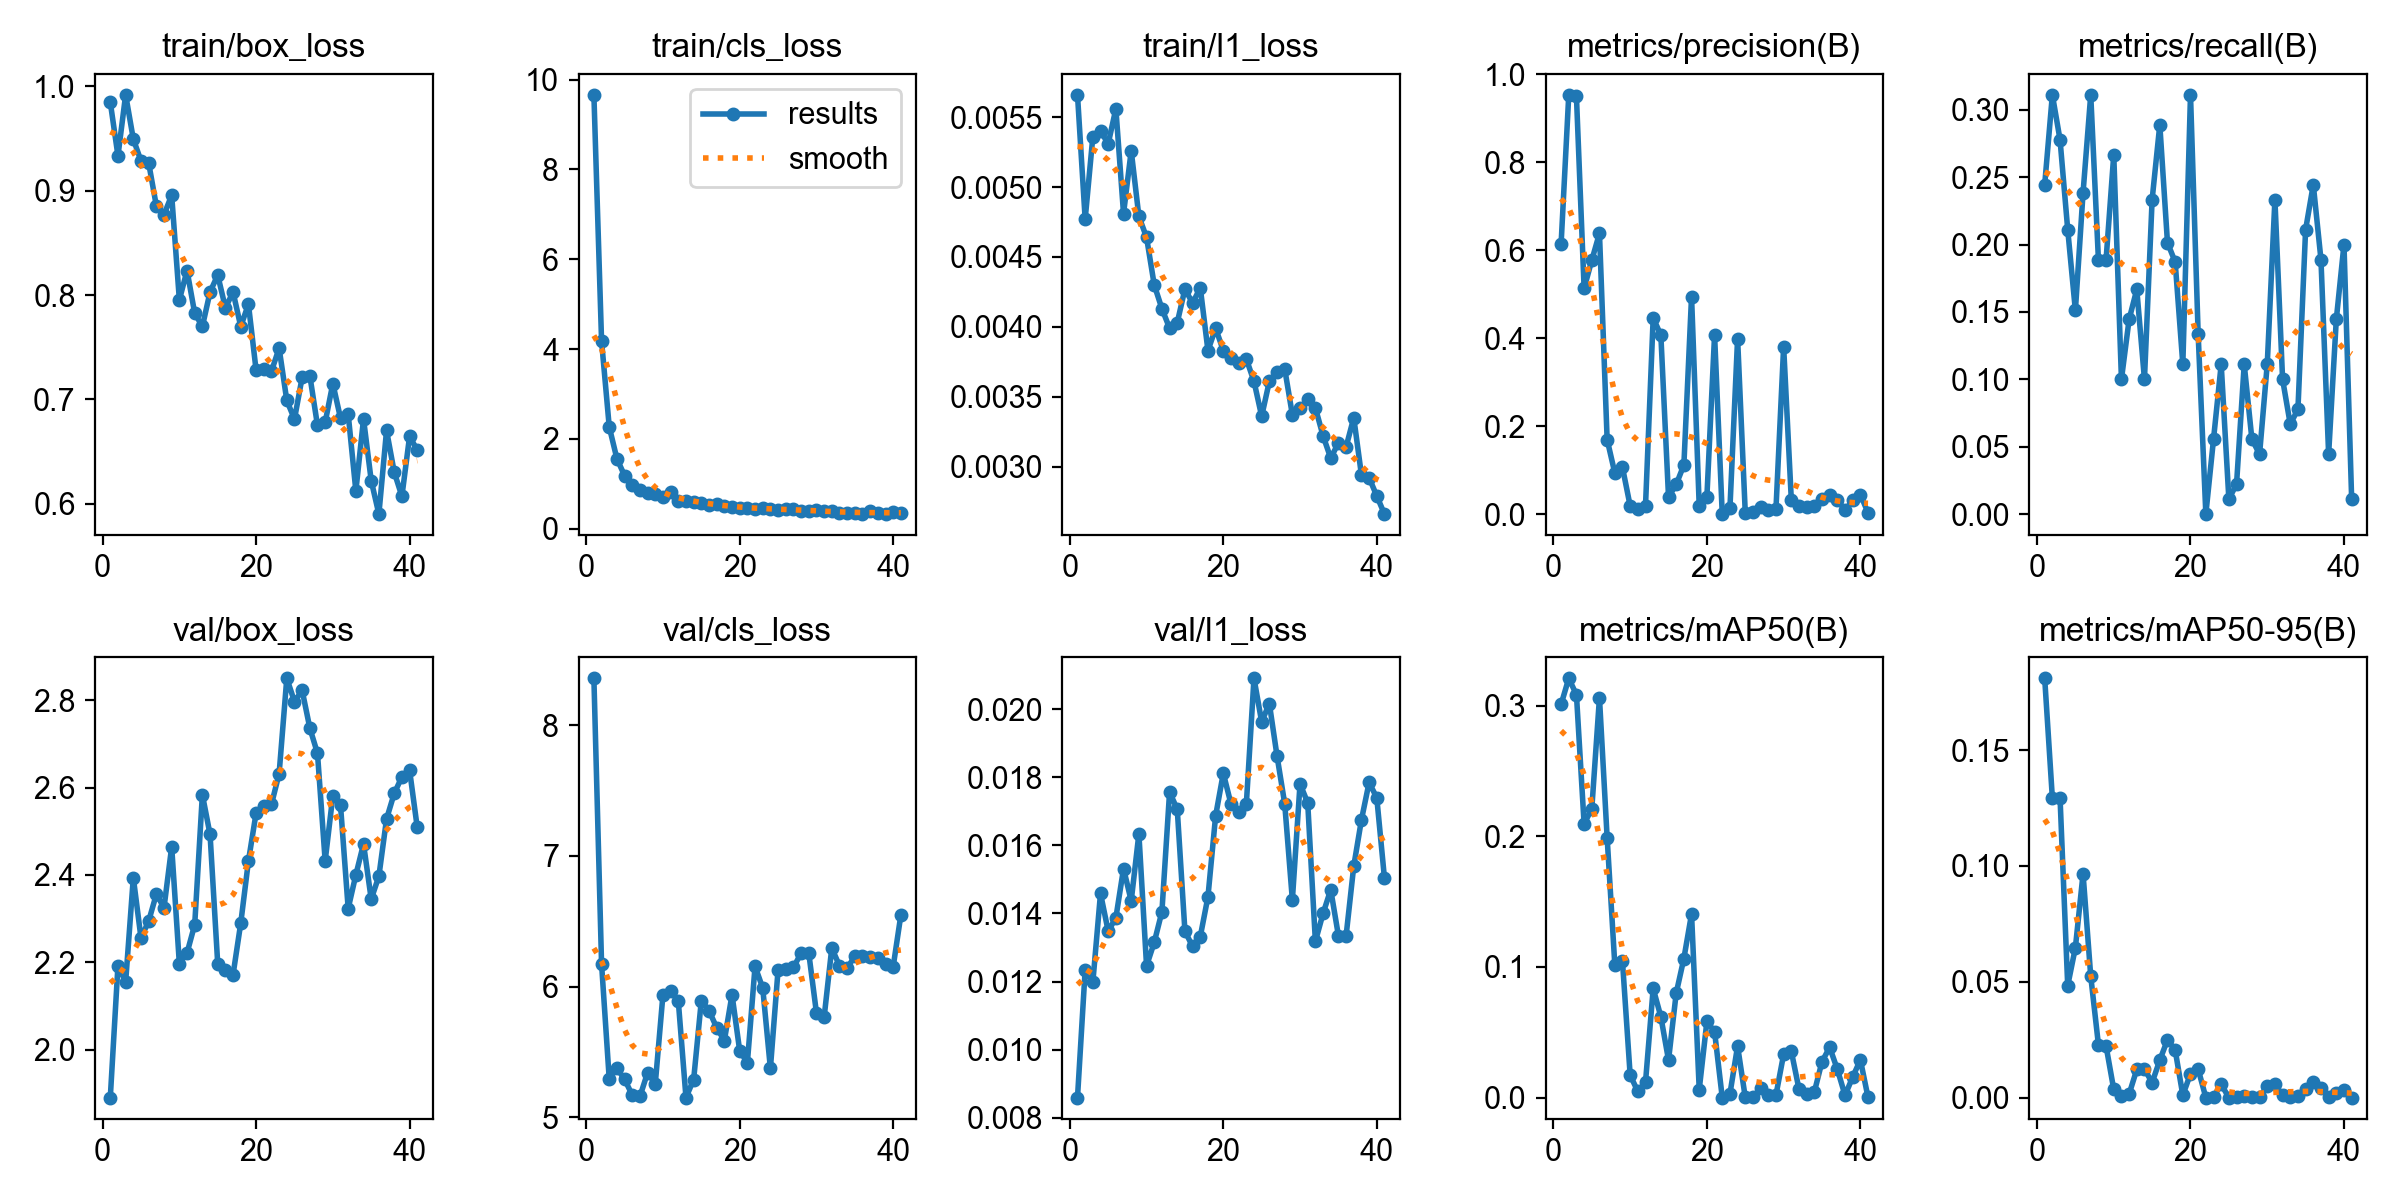

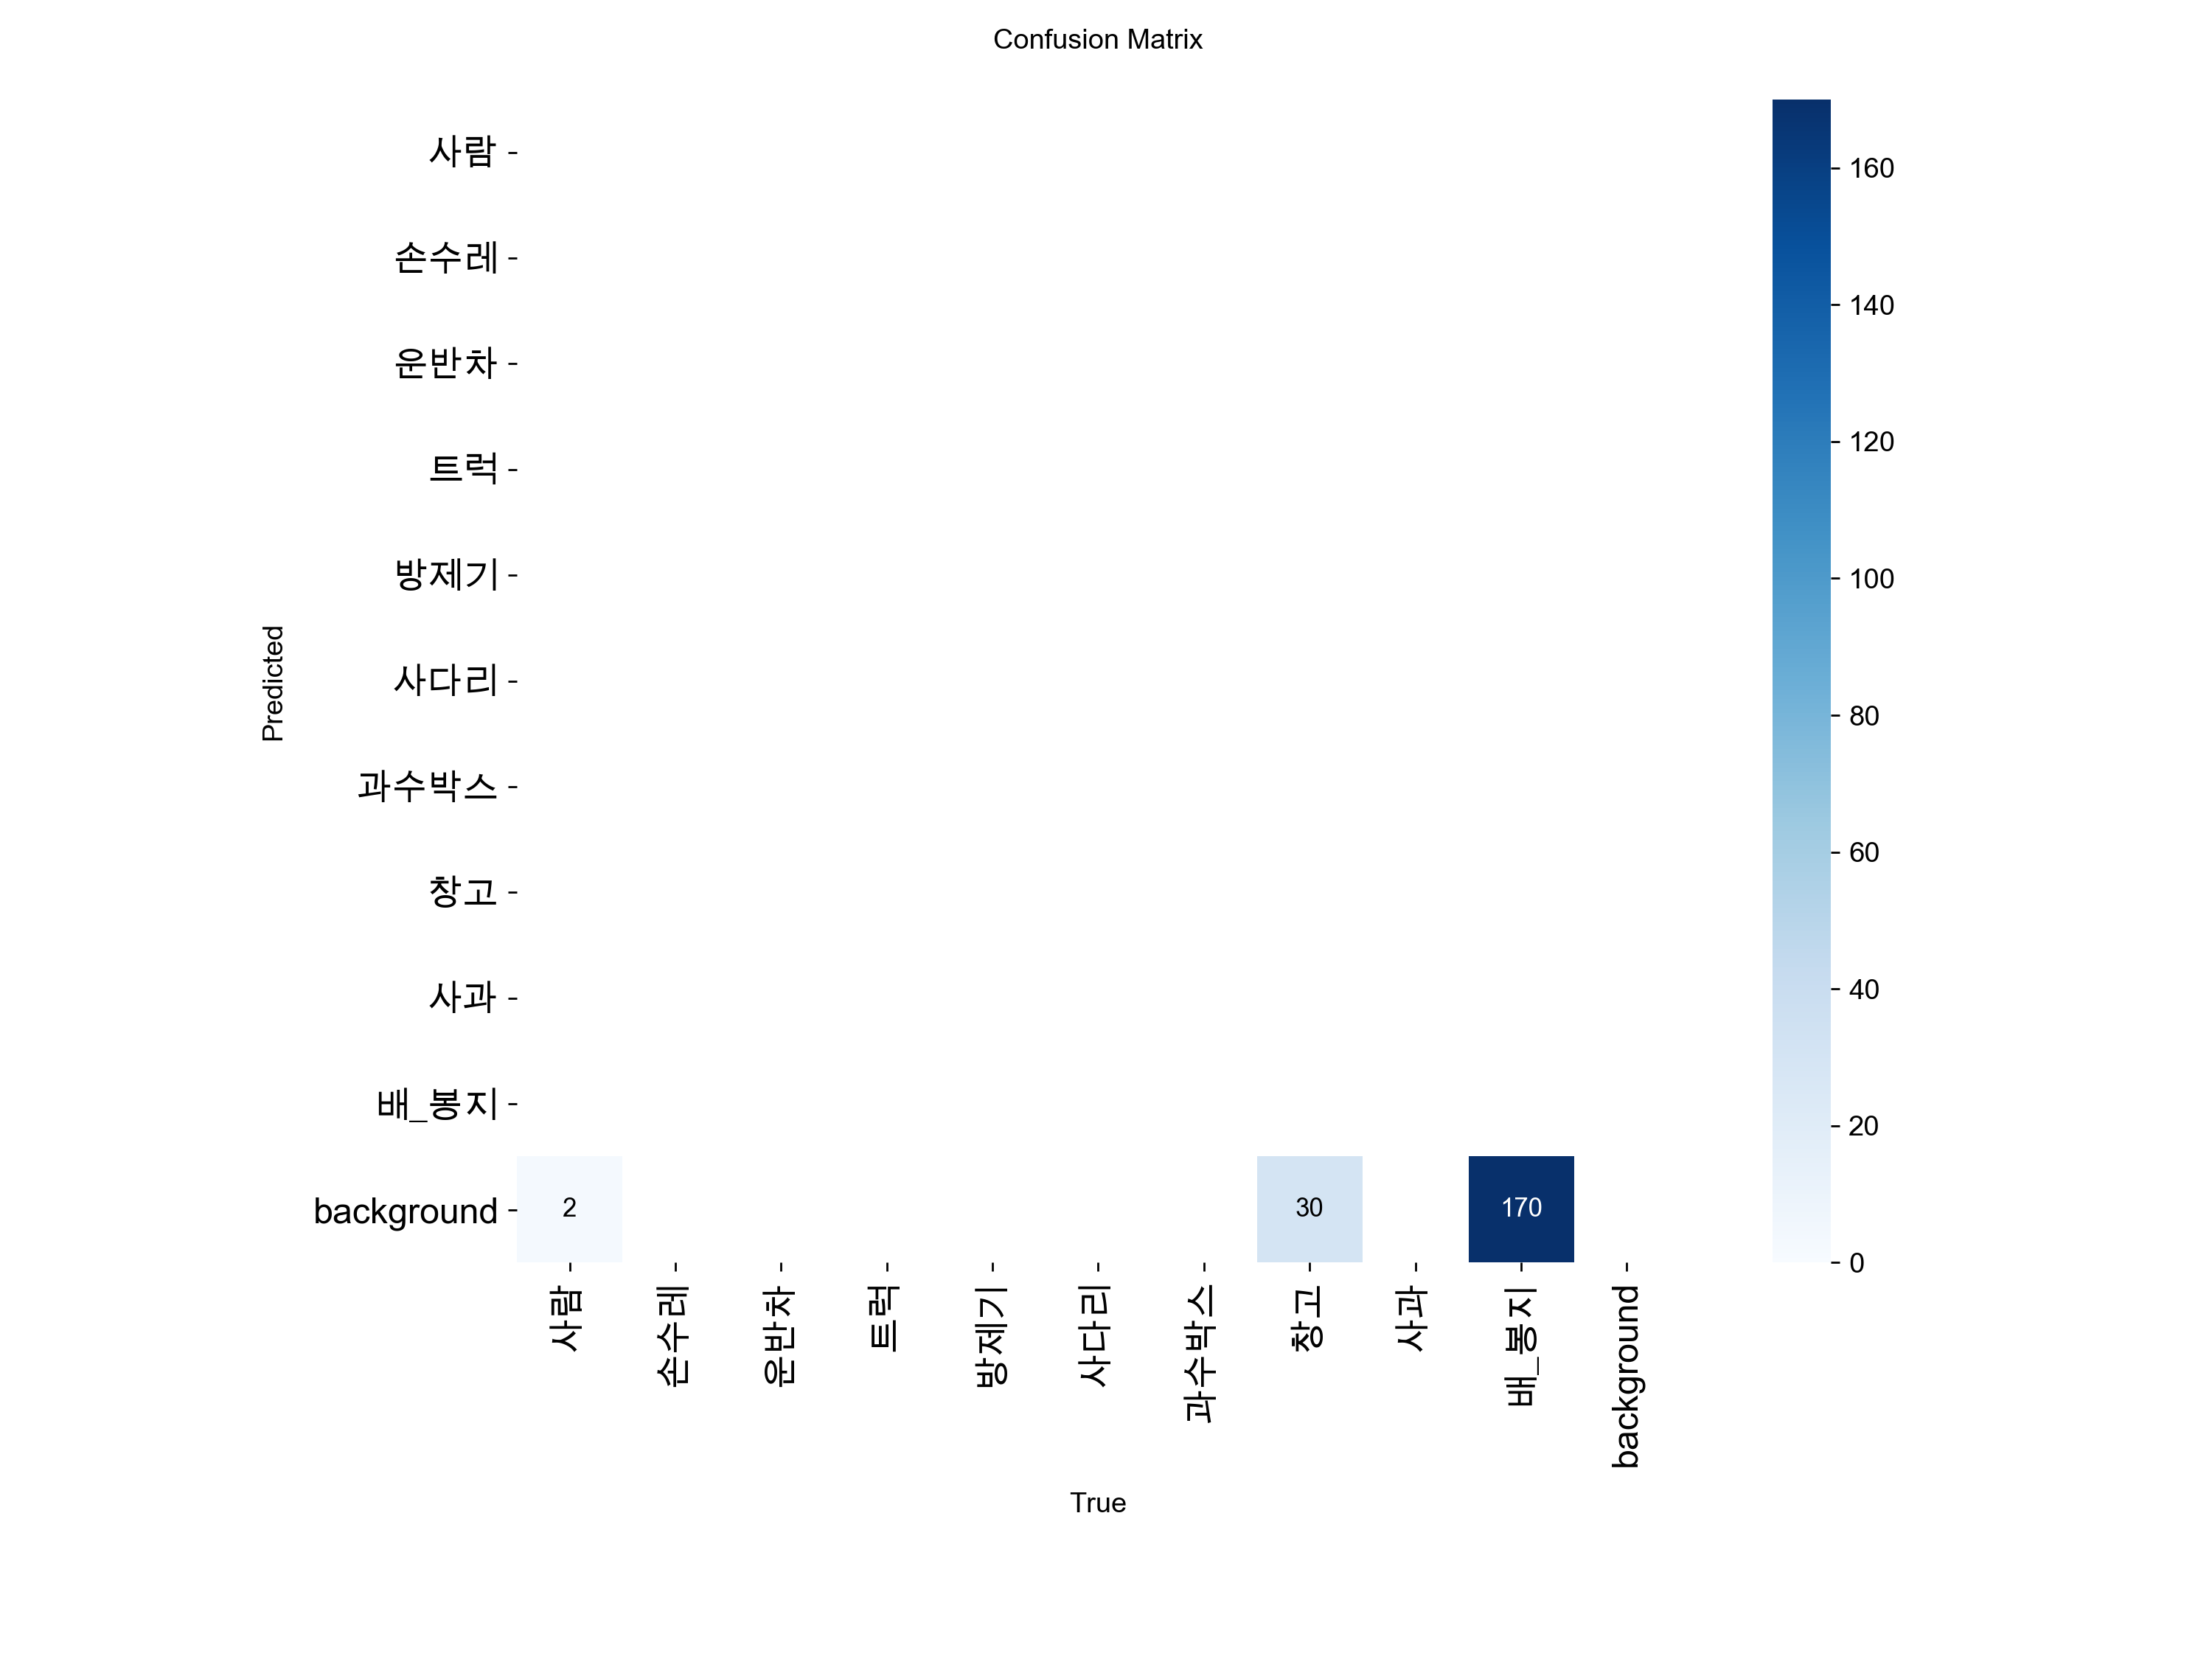

In [7]:
best_model = YOLO(str(BEST_WEIGHTS))
metrics = best_model.val(data=str(YAML_PATH), device=DEVICE)
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"mAP50    : {metrics.box.map50:.4f}")

probe_img = str(sorted((YOLO_DIR / "images" / "val").glob("*.jpg"))[0])
probe = best_model.predict(probe_img, conf=0.01, verbose=False)[0]
top_conf = max((float(b.conf) for b in probe.boxes), default=0.0)
print(f"샘플 최고 conf: {top_conf:.3f}  (현재 CONF_THRESH={CONF_THRESH})")
if top_conf < CONF_THRESH:
    print("⚠ confidence가 낮습니다. CONF_THRESH를 0.05~0.10으로 낮추세요.")

results_dir = BEST_WEIGHTS.parents[1]  # runs/detect/{EXPERIMENT}
for plot_name in ("results.png", "confusion_matrix.png"):
    plot_path = results_dir / plot_name
    if plot_path.exists():
        display(Image(filename=str(plot_path), width=720))

## 4. 이미지 추론 — 과수원 전방 객체 탐지

사과·배_봉지·사람(보행자)이 잘 보이는 **대표 3장**으로 추론합니다.


image 1/1 /content/orchard_robot_yolo/images/train/AP_002_HR_20231023_AM_000_000_001_0005_IMG.jpg: 384x640 21 사과s, 10.5ms
Speed: 1.7ms preprocess, 10.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/yolo26_orchard_robot_predict/AP_002_HR_20231023_AM_000_000_001_0005_IMG
  대표 클래스: 사과 | 탐지 {'사과': 21}
    사과: conf=0.665
    사과: conf=0.628
    사과: conf=0.490
    사과: conf=0.416
    사과: conf=0.378
    사과: conf=0.289
    사과: conf=0.288
    사과: conf=0.257
    사과: conf=0.236
    사과: conf=0.231
    사과: conf=0.209
    사과: conf=0.162
    사과: conf=0.152
    사과: conf=0.142
    사과: conf=0.136
    사과: conf=0.122
    사과: conf=0.120
    사과: conf=0.115
    사과: conf=0.105
    사과: conf=0.103
    사과: conf=0.101

[사과 | AP_002_HR_20231023_AM_000_000_001_0005_IMG.jpg]


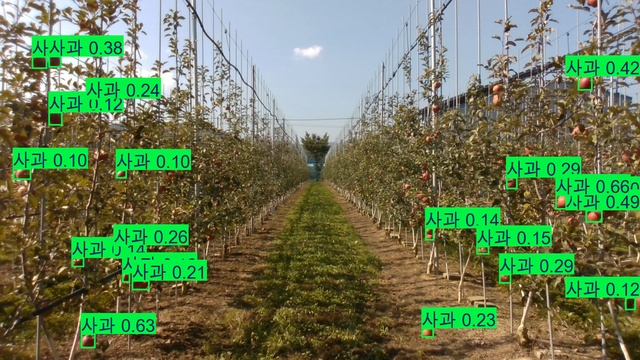

  저장 폴더: /content/runs/detect/yolo26_orchard_robot_predict/AP_002_HR_20231023_AM_000_000_001_0005_IMG

image 1/1 /content/orchard_robot_yolo/images/train/AP_001_TP_20231014_AM_000_000_000_0491_IMG.jpg: 384x640 1 운반차, 11.5ms
Speed: 1.8ms preprocess, 11.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/yolo26_orchard_robot_predict/AP_001_TP_20231014_AM_000_000_000_0491_IMG
  대표 클래스: 배_봉지 | 탐지 {'운반차': 1}
    운반차: conf=0.674

[배_봉지 | AP_001_TP_20231014_AM_000_000_000_0491_IMG.jpg]


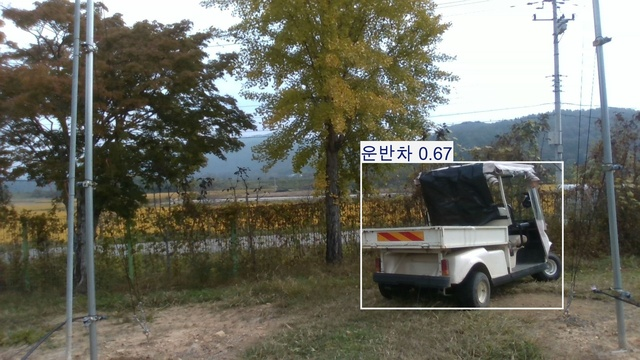

  저장 폴더: /content/runs/detect/yolo26_orchard_robot_predict/AP_001_TP_20231014_AM_000_000_000_0491_IMG

image 1/1 /content/orchard_robot_yolo/images/train/AP_001_HR_20230927_AM_000_002_000_0607_IMG.jpg: 384x640 2 사람s, 1 손수레, 3 과수박스s, 11.8ms
Speed: 1.8ms preprocess, 11.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/yolo26_orchard_robot_predict/AP_001_HR_20230927_AM_000_002_000_0607_IMG
  대표 클래스: 사람 | 탐지 {'사람': 2, '과수박스': 3, '손수레': 1}
    사람: conf=0.845
    과수박스: conf=0.772
    사람: conf=0.703
    과수박스: conf=0.349
    과수박스: conf=0.135
    손수레: conf=0.132

[사람 | AP_001_HR_20230927_AM_000_002_000_0607_IMG.jpg]


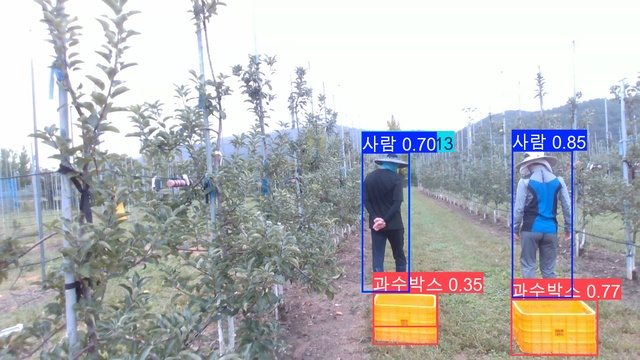

  저장 폴더: /content/runs/detect/yolo26_orchard_robot_predict/AP_001_HR_20230927_AM_000_002_000_0607_IMG


In [8]:
import cv2
from collections import Counter
from io import BytesIO
from PIL import Image as PILImage

PREDICT_DIR = ROOT / "runs" / "detect" / f"{EXPERIMENT}_predict"


def show_result_image(result, title: str = "", width: int = 640) -> None:
    """탐지 결과 이미지를 노트북 셀에 출력 (Windows 경로 이슈 회피)."""
    plotted = result.plot()
    rgb = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
    pil_img = PILImage.fromarray(rgb)
    if width and pil_img.width > width:
        ratio = width / pil_img.width
        pil_img = pil_img.resize((width, int(pil_img.height * ratio)), PILImage.LANCZOS)
    buf = BytesIO()
    pil_img.save(buf, format="JPEG", quality=95)
    if title:
        print(f"\n[{title}]")
    display(Image(data=buf.getvalue(), width=width))


def count_classes_in_label(txt_path: Path) -> Counter:
    cnt = Counter()
    for line in txt_path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        cid = int(line.split()[0])
        cnt[CLASS_NAMES[cid]] += 1
    return cnt


def pick_sample_by_class(class_name: str) -> Path:
    """시연용은 train에서 해당 클래스가 가장 많은 프레임을 고릅니다."""
    best_path, best_n = None, -1
    for txt in (YOLO_DIR / "labels" / "train").glob("*.txt"):
        n = count_classes_in_label(txt).get(class_name, 0)
        if n > best_n:
            img = YOLO_DIR / "images" / "train" / f"{txt.stem}.jpg"
            if img.exists():
                best_path, best_n = img, n
    if best_path is None:
        raise FileNotFoundError(f"{class_name} 샘플을 찾을 수 없습니다.")
    return best_path


SAMPLE_CLASSES = ["사과", "배_봉지", "사람"]
sample_images = [(name, pick_sample_by_class(name)) for name in SAMPLE_CLASSES]

for focus_name, img_path in sample_images:
    preds = best_model.predict(
        source=str(img_path),
        conf=CONF_THRESH,
        save=True,
        project=str(PREDICT_DIR),
        name=img_path.stem,
        exist_ok=True,
        device=DEVICE,
    )
    result = preds[0]
    if len(result.boxes) == 0:
        print(f"  ⚠ 탐지 0건 (conf={CONF_THRESH}) → 0.05로 재시도")
        result = best_model.predict(str(img_path), conf=0.05, device=DEVICE, verbose=False)[0]

    det = Counter(result.names[int(b.cls)] for b in result.boxes)
    print(f"  대표 클래스: {focus_name} | 탐지 {dict(det)}")
    for box in result.boxes:
        print(f"    {result.names[int(box.cls)]}: conf={float(box.conf):.3f}")

    show_result_image(result, title=f"{focus_name} | {img_path.name}")
    if getattr(result, "save_dir", None):
        print(f"  저장 폴더: {Path(result.save_dir).resolve()}")

## 5. 영상 추론 — 과수원 로봇 전방 모니터링

원본 데이터는 시퀀스 JPG이므로, 사람이 포함된 주행 시퀀스를 MP4로 만든 뒤 YOLO26 결과를 오버레이합니다.

모니터링 대상 시퀀스: AP_001_HR_20230927_AM_000_002_000
생성 영상: /content/orchard_robot_yolo/preview_drive.mp4

video 1/1 (frame 1/30) /content/orchard_robot_yolo/preview_drive.mp4: 384x640 2 사람s, 2 과수박스s, 1 사과, 12.0ms
frame 000: 사람=2, 차량류=0, 작물=1, 전체=5
video 1/1 (frame 2/30) /content/orchard_robot_yolo/preview_drive.mp4: 384x640 2 사람s, 1 사다리, 3 과수박스s, 2 사과s, 12.7ms
frame 001: 사람=2, 차량류=0, 작물=2, 전체=8
video 1/1 (frame 3/30) /content/orchard_robot_yolo/preview_drive.mp4: 384x640 2 사람s, 1 사다리, 5 과수박스s, 11.8ms
frame 002: 사람=2, 차량류=0, 작물=0, 전체=8
video 1/1 (frame 4/30) /content/orchard_robot_yolo/preview_drive.mp4: 384x640 2 사람s, 1 사다리, 4 과수박스s, 2 사과s, 11.9ms
video 1/1 (frame 5/30) /content/orchard_robot_yolo/preview_drive.mp4: 384x640 2 사람s, 3 과수박스s, 2 사과s, 12.4ms
video 1/1 (frame 6/30) /content/orchard_robot_yolo/preview_drive.mp4: 384x640 2 사람s, 4 과수박스s, 2 사과s, 12.4ms
video 1/1 (frame 7/30) /content/orchard_robot_yolo/preview_drive.mp4: 384x640 2 사람s, 2 과수박스s, 1 사과, 12.3ms
video 1/1 (frame 8/30) /co

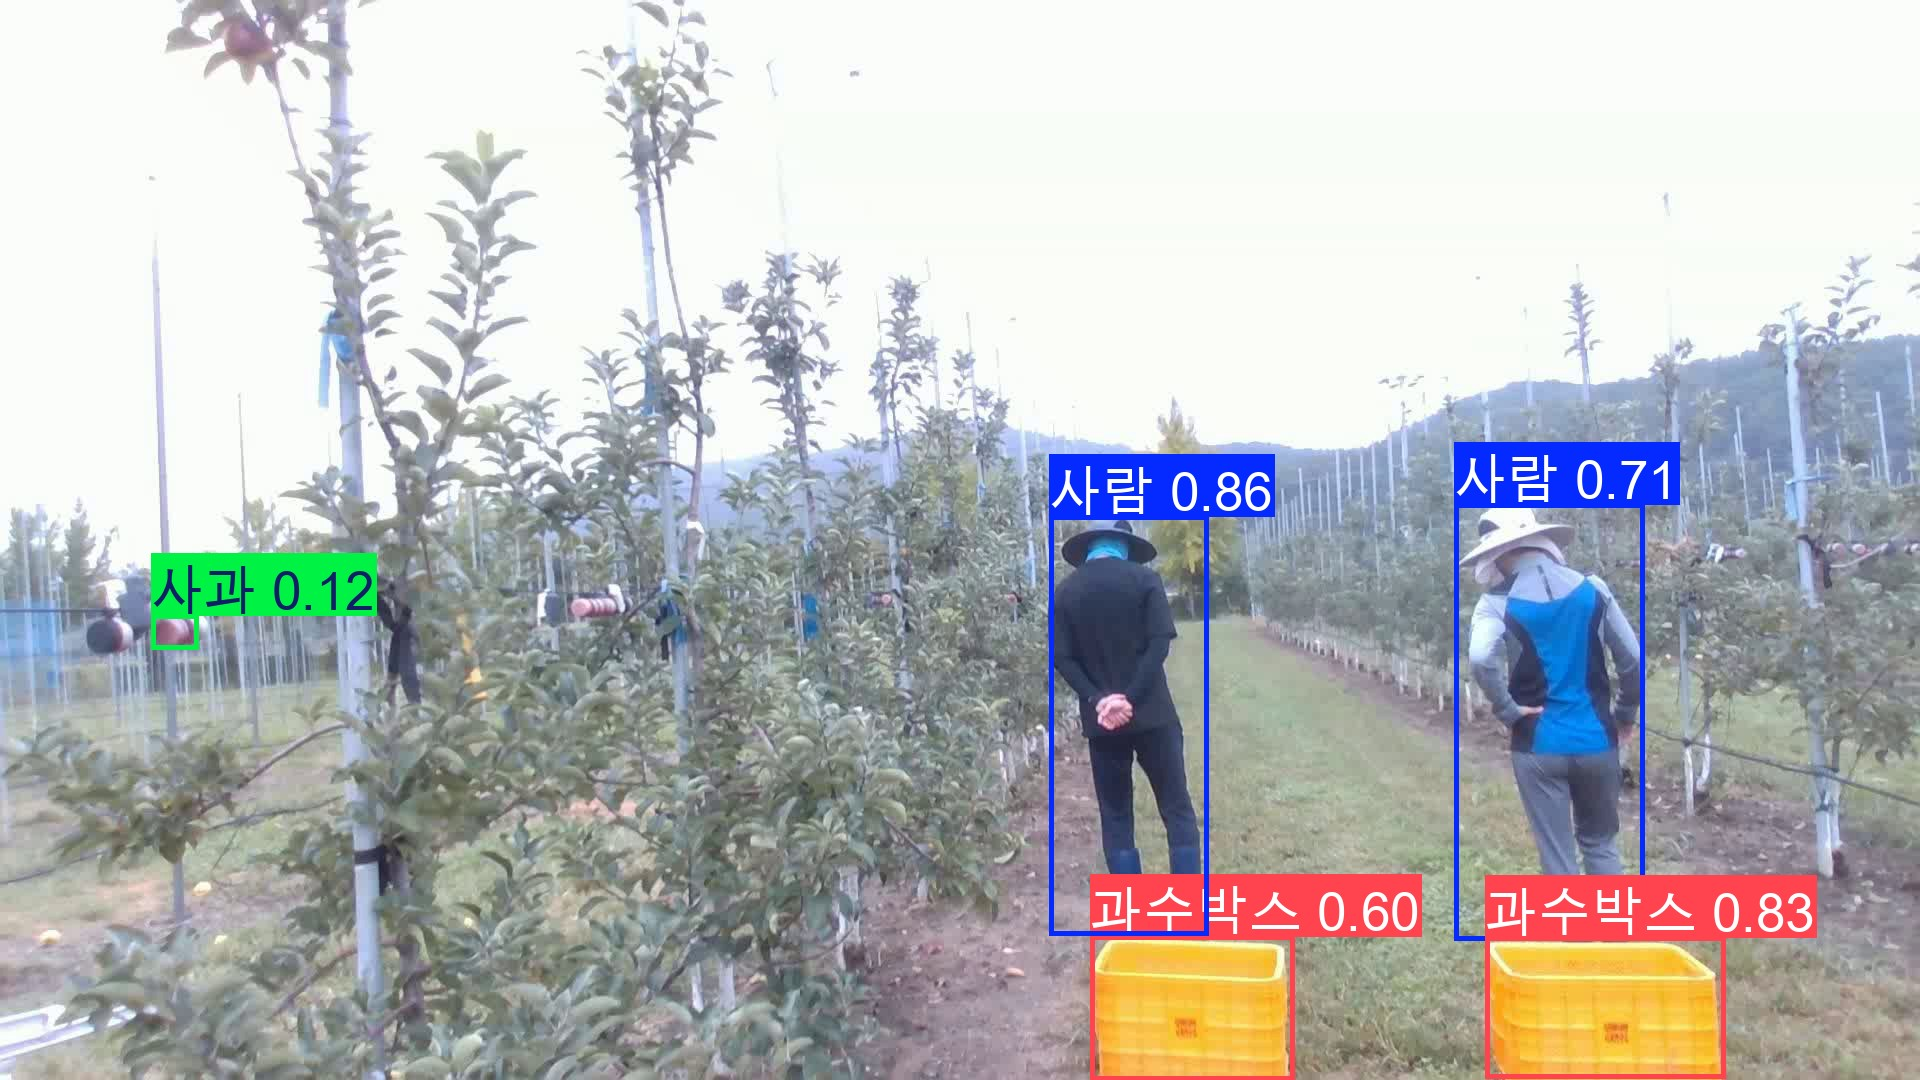

[샘플 frame 009]


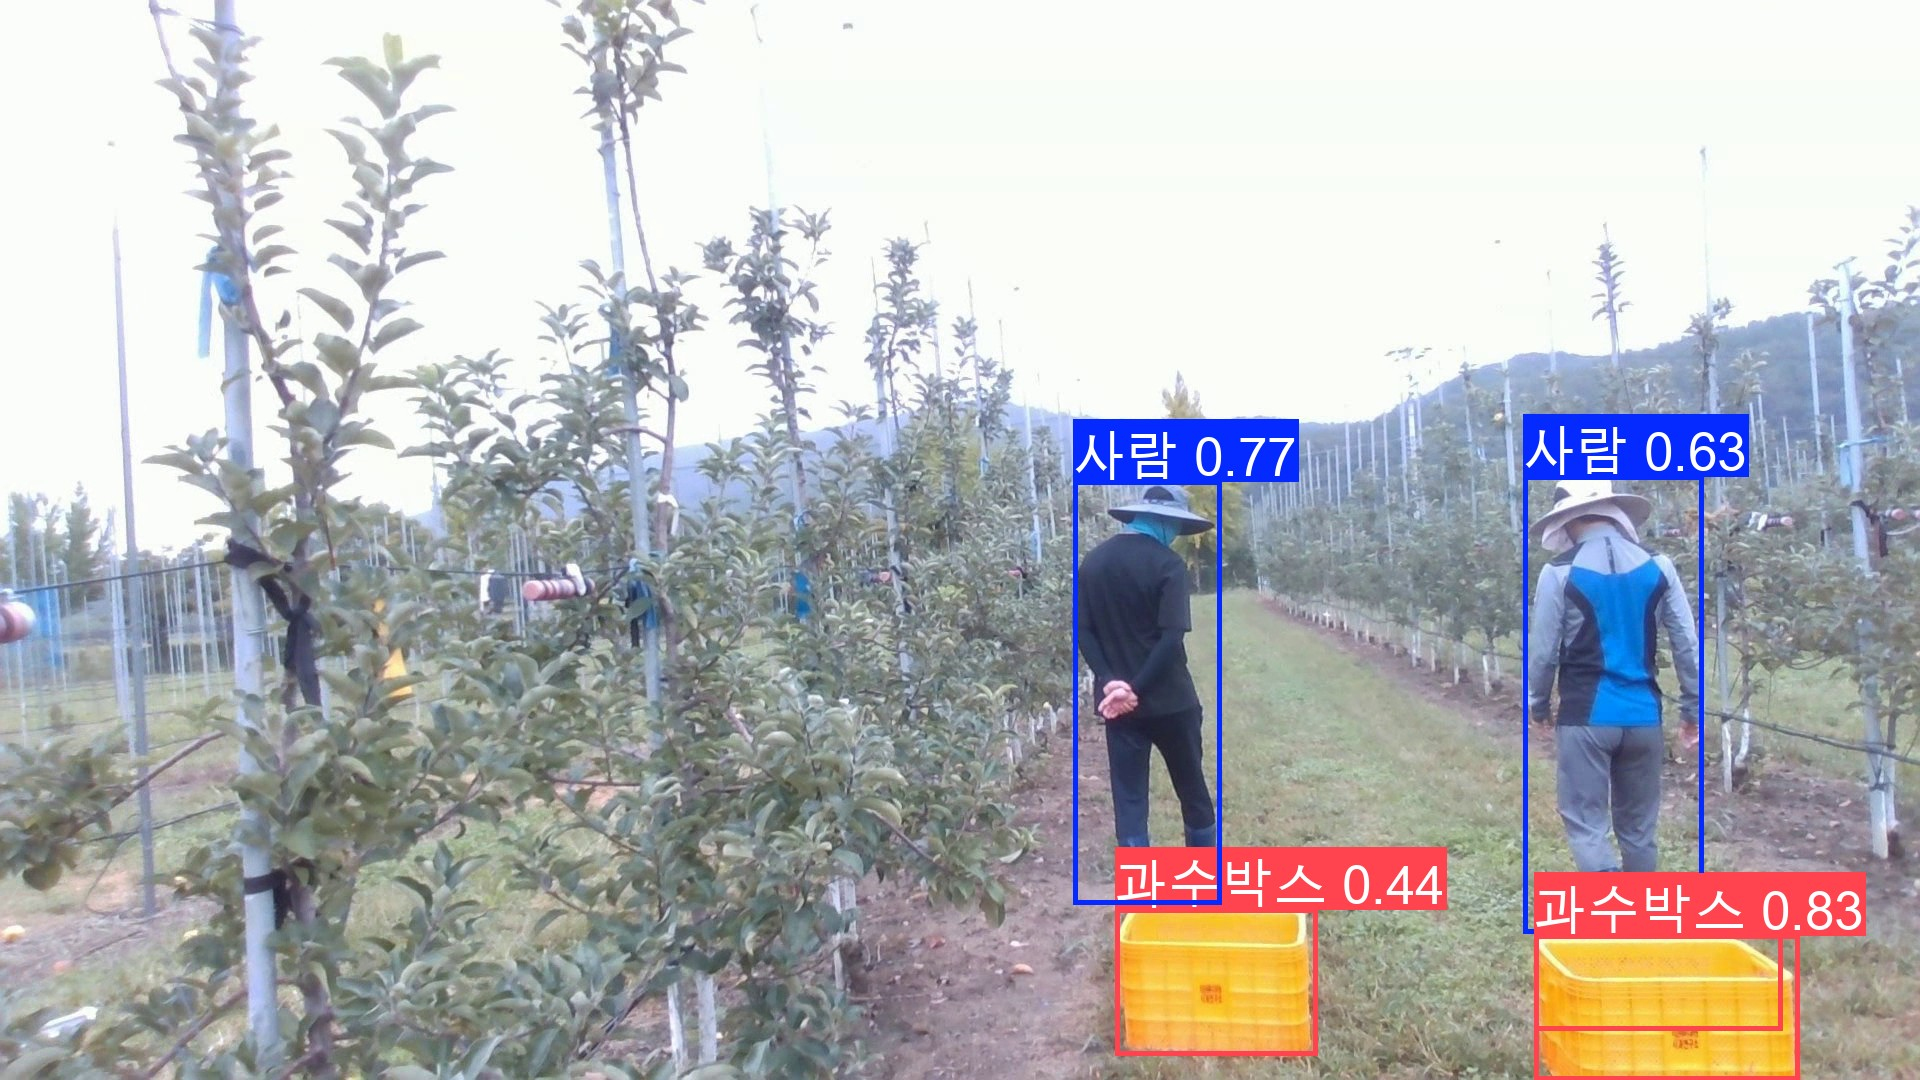

[샘플 frame 019]


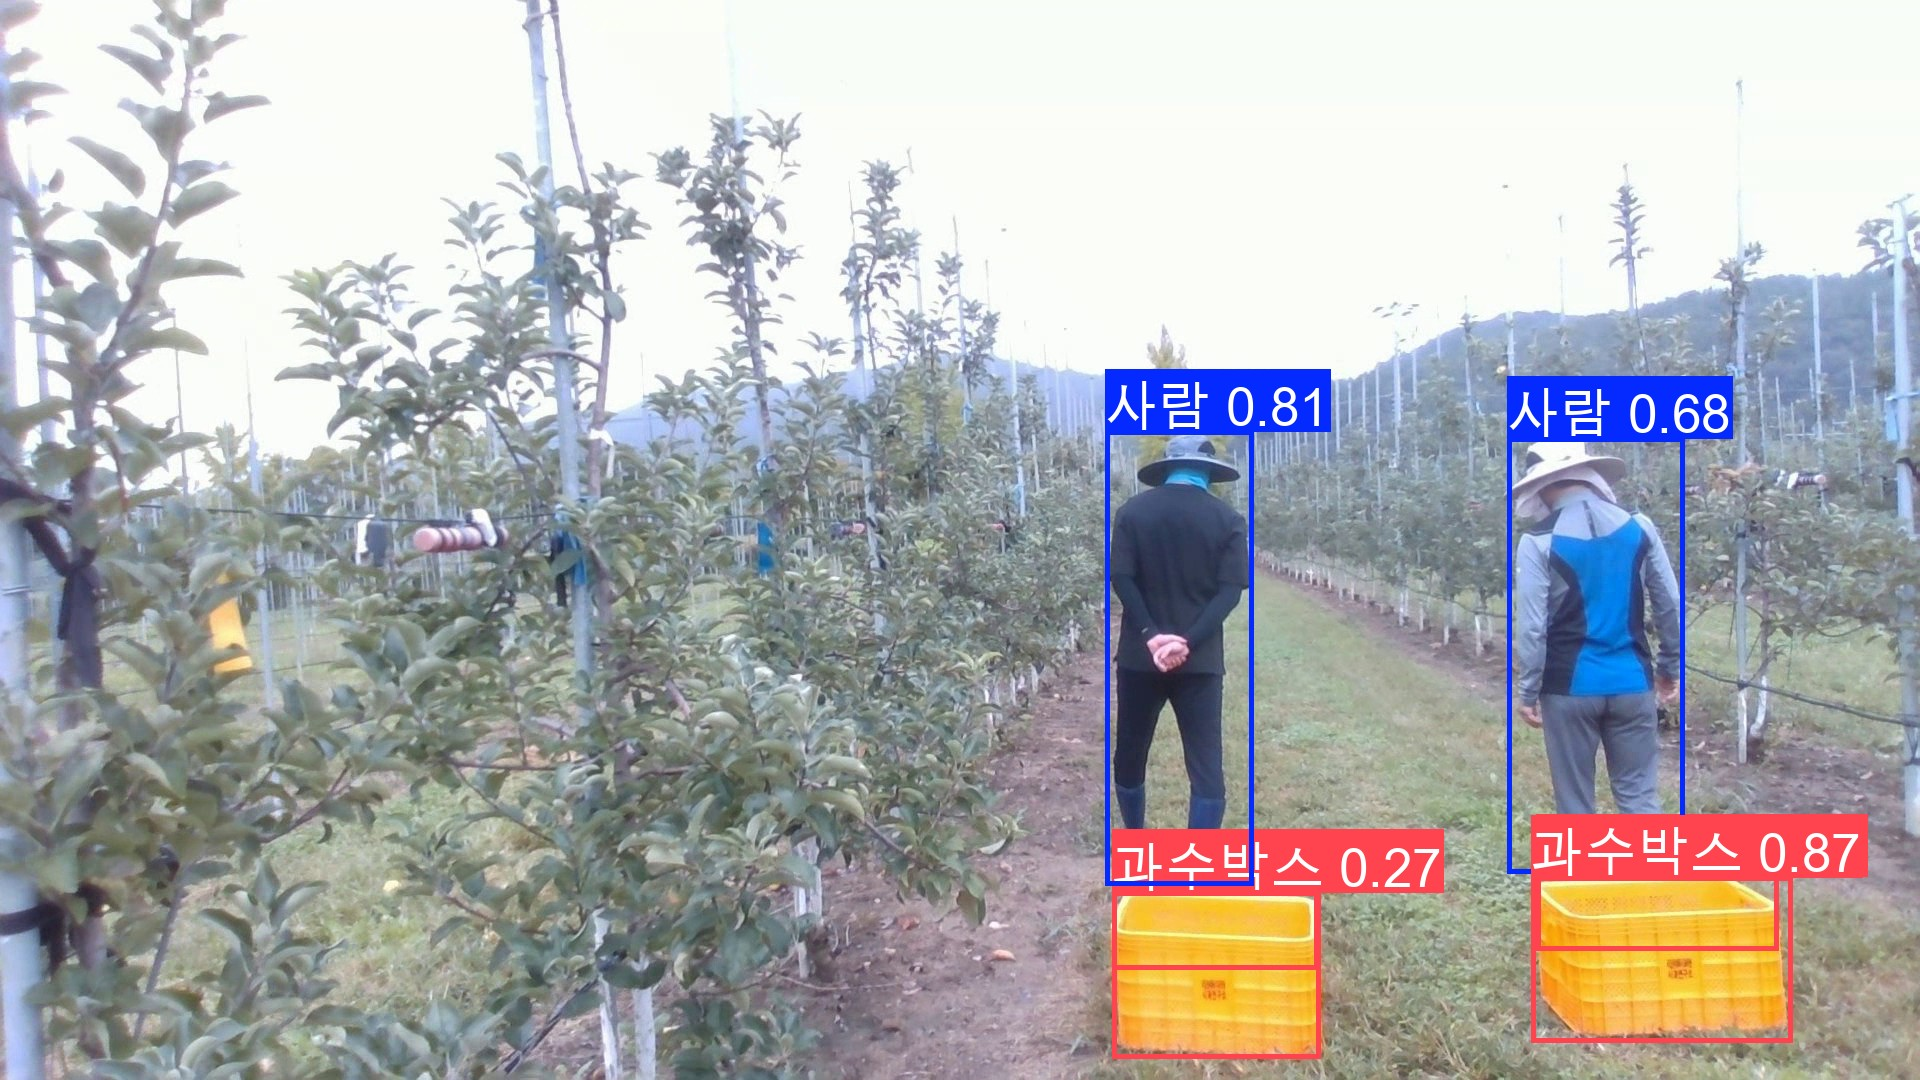


저장 파일: /content/runs/detect/yolo26_orchard_robot_predict/orchard_monitor/preview_drive.avi (.avi)
노트북 미리보기 GIF: /content/runs/detect/yolo26_orchard_robot_predict/orchard_monitor/preview_drive.preview.gif


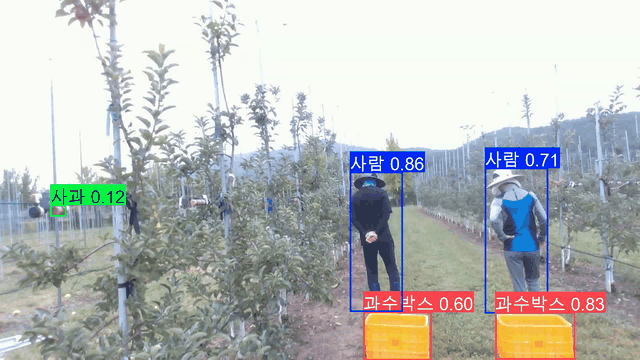

※ Colab: 왼쪽 파일 패널에서 해당 .avi/.mp4 를 다운로드해 재생하세요.


In [9]:
import cv2
from io import BytesIO
from IPython.display import Image, display
from PIL import Image as PILImage

raw_root, label_root = find_raw_and_label_roots(DATA_ROOT)


def sequence_person_count(seq_dir: Path) -> int:
    n = 0
    for jp in seq_dir.rglob("*_BBX.json"):
        data = json.loads(jp.read_text(encoding="utf-8-sig"))
        cats = {c["id"]: c["name"] for c in data.get("categories", [])}
        n += sum(1 for a in data.get("annotations", []) if cats.get(a.get("category_id")) == "사람")
    return n


def pick_drive_sequence() -> Path:
    best, best_n = None, -1
    for seq in label_root.rglob("*"):
        if not seq.is_dir() or seq.name in {"BBX", "CUB", "SEG"}:
            continue
        if not (seq / "BBX").exists():
            continue
        n = sequence_person_count(seq)
        if n > best_n:
            best, best_n = seq, n
    if best is None:
        raise FileNotFoundError("BBX 시퀀스를 찾을 수 없습니다.")
    return best


def sequence_to_mp4(seq_label_dir: Path, out_path: Path, fps: int = 8) -> Path:
    rel = seq_label_dir.relative_to(label_root)
    img_dir = raw_root / rel / "IMG"
    frames = sorted(img_dir.glob("*.jpg"))
    if not frames:
        raise FileNotFoundError(f"이미지가 없습니다: {img_dir}")
    first = cv2.imread(str(frames[0]))
    h, w = first.shape[:2]
    out_path.parent.mkdir(parents=True, exist_ok=True)
    writer = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
    for fp in frames:
        frame = cv2.imread(str(fp))
        if frame is not None:
            writer.write(frame)
    writer.release()
    return out_path


drive_seq = pick_drive_sequence()
video_path = sequence_to_mp4(drive_seq, YOLO_DIR / "preview_drive.mp4")
print(f"모니터링 대상 시퀀스: {drive_seq.name}")
print(f"생성 영상: {video_path.resolve()}")

video_preds = best_model.predict(
    source=str(video_path),
    conf=CONF_THRESH,
    save=True,
    project=str(PREDICT_DIR),
    name="orchard_monitor",
    exist_ok=True,
    device=DEVICE,
    stream=True,
)

frame_alerts = 0
sample_frames: dict[int, object] = {}
last_result = None
for i, result in enumerate(video_preds):
    last_result = result
    names = [result.names[int(b.cls)] for b in result.boxes]
    n_person = names.count("사람")
    n_vehicle = sum(names.count(k) for k in ("손수레", "운반차", "트럭", "방제기"))
    n_crop = names.count("사과") + names.count("배_봉지")
    if n_person > 0:
        frame_alerts += 1
    if i < 3:
        print(f"frame {i:03d}: 사람={n_person}, 차량류={n_vehicle}, 작물={n_crop}, 전체={len(names)}")
    if i in (0, 9, 19):
        sample_frames[i] = result

print(f"\n총 프레임: {i + 1}, 사람 감지 프레임: {frame_alerts}")

for idx, result in sample_frames.items():
    plotted = result.plot()
    rgb = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
    pil_img = PILImage.fromarray(rgb)
    buf = BytesIO()
    pil_img.save(buf, format="JPEG", quality=90)
    print(f"[샘플 frame {idx:03d}]")
    display(Image(data=buf.getvalue(), width=640))


def find_saved_video(search_dirs: list[Path]) -> Path | None:
    for folder in search_dirs:
        if not folder.exists():
            continue
        for ext in ("*.mp4", "*.avi", "*.mkv"):
            found = sorted(folder.rglob(ext))
            if found:
                return found[0]
    return None


def make_gif_preview(
    video_path: Path,
    gif_path: Path,
    every_n: int = 3,
    max_frames: int = 24,
    width: int = 640,
) -> Path:
    cap = cv2.VideoCapture(str(video_path))
    frames: list[PILImage.Image] = []
    idx = 0
    while len(frames) < max_frames:
        ok, frame = cap.read()
        if not ok:
            break
        if idx % every_n == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil = PILImage.fromarray(rgb)
            if pil.width > width:
                ratio = width / pil.width
                pil = pil.resize((width, int(pil.height * ratio)), PILImage.LANCZOS)
            frames.append(pil)
        idx += 1
    cap.release()
    if not frames:
        raise RuntimeError(f"GIF 생성 실패: {video_path}")
    frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=150, loop=0)
    return gif_path


out_video_dir = Path(last_result.save_dir) if last_result else PREDICT_DIR / "orchard_monitor"
saved_video = find_saved_video([out_video_dir, PREDICT_DIR / "orchard_monitor", PREDICT_DIR])

if saved_video:
    print(f"\n저장 파일: {saved_video.resolve()} ({saved_video.suffix})")
    gif_path = saved_video.with_suffix(".preview.gif")
    make_gif_preview(saved_video, gif_path)
    print(f"노트북 미리보기 GIF: {gif_path.resolve()}")
    with open(gif_path, "rb") as f:
        display(Image(data=f.read(), width=640))
    print("※ Colab: 왼쪽 파일 패널에서 해당 .avi/.mp4 를 다운로드해 재생하세요.")
else:
    print("저장된 영상을 찾지 못했습니다. 아래 폴더를 확인하세요:")
    print(out_video_dir.resolve())

## 6. CLI 참고 명령어

```bash
# 학습 (섹션 1에서 YOLO 데이터셋 변환 후 실행)
yolo detect train model=yolo26s.pt data=orchard_robot_yolo/orchard_robot.yaml epochs=80 imgsz=640 batch=8 device=0 name=yolo26_orchard_robot

# 시퀀스로 만든 주행 영상 추론
yolo predict model=runs/detect/yolo26_orchard_robot/weights/best.pt source=orchard_robot_yolo/preview_drive.mp4 conf=0.10 save=True
```

## 7. JSON 기반 의미 정보 구조화 & 객체 관계 정의

YOLO가 반환하는 bbox·클래스·confidence를 **장면(scene) 단위 JSON**으로 정리하고,  
과수원 로봇 관점의 **공간 관계**(충돌 위험, 수확 수집)를 정의하는 실습입니다.

| 단계 | 내용 |
|------|------|
| 7-1 | 탐지 결과 → 의미 객체(JSON) 변환 |
| 7-2 | 객체 쌍 관계 추론 & JSON 저장 |

In [10]:
# ── 7-1. YOLO 탐지 결과 → JSON 기반 의미 정보 구조화 ──
from datetime import datetime, timezone
import json
import math

SEMANTIC_ROLES = {
    "사람": "pedestrian",
    "손수레": "moving_obstacle",
    "운반차": "moving_obstacle",
    "트럭": "moving_obstacle",
    "방제기": "moving_obstacle",
    "사다리": "static_obstacle",
    "과수박스": "harvest_container",
    "창고": "static_obstacle",
    "사과": "crop",
    "배_봉지": "crop",
}


def box_center(xyxy: list[float]) -> list[float]:
    x1, y1, x2, y2 = xyxy
    return [(x1 + x2) / 2, (y1 + y2) / 2]


def xyxy_to_xywh(xyxy: list[float]) -> list[float]:
    x1, y1, x2, y2 = xyxy
    return [x1, y1, x2 - x1, y2 - y1]


def result_to_semantic_json(result, scene_id: str | None = None) -> dict:
    h, w = result.orig_shape
    objects = []
    for i, box in enumerate(result.boxes):
        cls_name = result.names[int(box.cls)]
        xyxy = [round(float(v), 1) for v in box.xyxy[0].tolist()]
        objects.append({
            "id": f"obj_{i}",
            "class": cls_name,
            "semantic_role": SEMANTIC_ROLES.get(cls_name, cls_name),
            "confidence": round(float(box.conf), 4),
            "bbox_xyxy": xyxy,
            "bbox_xywh": [round(v, 1) for v in xyxy_to_xywh(xyxy)],
            "center": [round(v, 1) for v in box_center(xyxy)],
        })

    counts = {name: sum(1 for o in objects if o["class"] == name) for name in CLASS_NAMES}
    counts["total"] = len(objects)
    return {
        "scene_id": scene_id or Path(result.path).stem,
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "image": {"path": str(result.path), "width": w, "height": h},
        "detector": {"model": EXPERIMENT, "conf_threshold": CONF_THRESH},
        "objects": objects,
        "counts": counts,
    }


demo_img = sample_images[2][1]  # 사람 대표 샘플
demo_result = best_model.predict(str(demo_img), conf=CONF_THRESH, device=DEVICE, verbose=False)[0]
scene_json = result_to_semantic_json(demo_result)

print(json.dumps(scene_json, ensure_ascii=False, indent=2))

SEMANTIC_DIR = PREDICT_DIR / "semantic_json"
SEMANTIC_DIR.mkdir(parents=True, exist_ok=True)
json_path = SEMANTIC_DIR / f"{scene_json['scene_id']}.json"
json_path.write_text(json.dumps(scene_json, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"\n저장: {json_path.resolve()}")

{
  "scene_id": "AP_001_HR_20230927_AM_000_002_000_0607_IMG",
  "timestamp": "2026-09-07T08:45:17.731603+00:00",
  "image": {
    "path": "/content/orchard_robot_yolo/images/train/AP_001_HR_20230927_AM_000_002_000_0607_IMG.jpg",
    "width": 1920,
    "height": 1080
  },
  "detector": {
    "model": "yolo26_orchard_robot",
    "conf_threshold": 0.1
  },
  "objects": [
    {
      "id": "obj_0",
      "class": "사람",
      "semantic_role": "pedestrian",
      "confidence": 0.8451,
      "bbox_xyxy": [
        1536.0,
        450.8,
        1718.7,
        894.0
      ],
      "bbox_xywh": [
        1536.0,
        450.8,
        182.7,
        443.2
      ],
      "center": [
        1627.3,
        672.4
      ]
    },
    {
      "id": "obj_1",
      "class": "과수박스",
      "semantic_role": "harvest_container",
      "confidence": 0.7721,
      "bbox_xyxy": [
        1532.9,
        897.3,
        1794.9,
        1067.6
      ],
      "bbox_xywh": [
        1532.9,
        897.3,
      

In [11]:
# ── 7-2. 탐지된 객체 간 관계 정의 실습 ──
# subject --[predicate]--> object 형태의 트리플(triple)로 공간 관계를 표현

MOVING = {"손수레", "운반차", "트럭", "방제기"}
STATIC = {"사다리", "과수박스", "창고"}
CROP = {"사과", "배_봉지"}


def bbox_iou(a: list[float], b: list[float]) -> float:
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1, inter_y1 = max(ax1, bx1), max(ay1, by1)
    inter_x2, inter_y2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0.0, inter_x2 - inter_x1) * max(0.0, inter_y2 - inter_y1)
    if inter == 0:
        return 0.0
    area_a = (ax2 - ax1) * (ay2 - ay1)
    area_b = (bx2 - bx1) * (by2 - by1)
    return inter / (area_a + area_b - inter)


def center_distance(a: list[float], b: list[float]) -> float:
    return math.hypot(a[0] - b[0], a[1] - b[1])


def pair_relation(left: dict, right: dict, near_px: float, hazard_iou: float) -> dict | None:
    iou = bbox_iou(left["bbox_xyxy"], right["bbox_xyxy"])
    dist = center_distance(left["center"], right["center"])
    lc, rc = left["class"], right["class"]

    if lc == "사람" and rc in MOVING:
        if iou >= hazard_iou:
            predicate, risk, semantic = "overlaps_with", "high", "collision_hazard_overlap"
        elif dist <= near_px:
            predicate, risk, semantic = "near", "medium", "pedestrian_near_vehicle"
        else:
            predicate, risk, semantic = "far_from", "low", "safe_distance"
    elif lc == "사람" and rc in STATIC:
        if dist <= near_px:
            predicate, risk, semantic = "near", "medium", "worker_near_structure"
        else:
            predicate, risk, semantic = "far_from", "low", "clear_path"
    elif lc in CROP and rc == "과수박스":
        if dist <= near_px:
            predicate, risk, semantic = "near", "low", "harvest_collection"
        else:
            return None
    else:
        return None

    return {
        "subject": left["id"],
        "predicate": predicate,
        "object": right["id"],
        "metrics": {"iou": round(iou, 4), "center_distance_px": round(dist, 1)},
        "semantic": semantic,
        "risk_level": risk,
        "pair": f"{lc}-{rc}",
    }


def infer_relationships(scene: dict, near_px: float = 220.0, hazard_iou: float = 0.05) -> list[dict]:
    """과수원 로봇 주행 기준 공간 관계 정의.

    규칙:
      - 사람 × 차량류  IoU 큼 → overlaps_with (충돌 위험, high)
      - 사람 × 차량류  근접   → near (보행자 주의, medium)
      - 사람 × 고정물  근접   → near (작업/장애물, medium)
      - 작물 × 과수박스 근접 → harvest_collection
    """
    objs = scene["objects"]
    relations = []
    for a in objs:
        for b in objs:
            if a["id"] == b["id"]:
                continue
            rel = pair_relation(a, b, near_px, hazard_iou)
            if rel:
                relations.append(rel)
    return relations


def enrich_scene_with_relations(scene: dict, **kwargs) -> dict:
    enriched = dict(scene)
    enriched["relationships"] = infer_relationships(scene, **kwargs)
    risks = [r["risk_level"] for r in enriched["relationships"]]
    if "high" in risks:
        alert = "collision_hazard_detected"
    elif "medium" in risks:
        alert = "pedestrian_or_obstacle_near"
    elif enriched["relationships"]:
        alert = "harvest_context"
    else:
        alert = "normal"
    enriched["scene_summary"] = {
        "alert": alert,
        "relation_count": len(enriched["relationships"]),
        "max_risk": max(risks, default="none"),
    }
    return enriched


scene_enriched = enrich_scene_with_relations(scene_json)

print("=== 객체 관계 (relationships) ===")
for rel in scene_enriched["relationships"]:
    print(
        f"  {rel['subject']} --[{rel['predicate']}]--> {rel['object']}"
        f" | {rel['semantic']} (risk={rel['risk_level']}, dist={rel['metrics']['center_distance_px']}px)"
    )

print("\n=== 장면 요약 ===")
print(json.dumps(scene_enriched["scene_summary"], ensure_ascii=False, indent=2))

enriched_path = SEMANTIC_DIR / f"{scene_enriched['scene_id']}_enriched.json"
enriched_path.write_text(json.dumps(scene_enriched, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"\n저장: {enriched_path.resolve()}")

print("\n=== 대표 3장 관계 비교 ===")
for focus_name, img_path in sample_images:
    r = best_model.predict(str(img_path), conf=CONF_THRESH, device=DEVICE, verbose=False)[0]
    s = enrich_scene_with_relations(result_to_semantic_json(r))
    print(f"  [{focus_name}] alert={s['scene_summary']['alert']}, relations={s['scene_summary']['relation_count']}")

=== 객체 관계 (relationships) ===
  obj_0 --[far_from]--> obj_1 | clear_path (risk=low, dist=312.2px)
  obj_0 --[far_from]--> obj_3 | clear_path (risk=low, dist=499.5px)
  obj_0 --[far_from]--> obj_4 | clear_path (risk=low, dist=485.5px)
  obj_0 --[far_from]--> obj_5 | safe_distance (risk=low, dist=469.2px)
  obj_2 --[far_from]--> obj_1 | clear_path (risk=low, dist=596.3px)
  obj_2 --[far_from]--> obj_3 | clear_path (risk=low, dist=295.0px)
  obj_2 --[far_from]--> obj_4 | clear_path (risk=low, dist=268.8px)
  obj_2 --[overlaps_with]--> obj_5 | collision_hazard_overlap (risk=high, dist=2.4px)

=== 장면 요약 ===
{
  "alert": "collision_hazard_detected",
  "relation_count": 8,
  "max_risk": "low"
}

저장: /content/runs/detect/yolo26_orchard_robot_predict/semantic_json/AP_001_HR_20230927_AM_000_002_000_0607_IMG_enriched.json

=== 대표 3장 관계 비교 ===
  [사과] alert=normal, relations=0
  [배_봉지] alert=normal, relations=0
  [사람] alert=collision_hazard_detected, relations=8
